# Probe & baseline results

Reads whatever is in `runs/`. Loads no model, needs no GPU. This is for
looking at results, not producing them.

The question behind all of it: **does the model know enough chess for RL to
have anything to amplify?** RL boosts responses a model already gives
sometimes. It cannot install a missing capability.

In [1]:
%matplotlib inline
import json
import re
import statistics as st
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

from plot import INK, INK_SOFT, SERIES, SURFACE, style

RUNS = Path("runs")
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]

for path in sorted(RUNS.glob("*.json")):
    print(f"{path.name:26s} {path.stat().st_size / 1024:6.0f} KB")

movetext-nothink.json          37 KB
movetext-think.json           182 KB
p1024-0.6b.json                37 KB
p1024-1.7b.json                87 KB
p1024-4b.json                  97 KB


## 1. Capability probe across model sizes

`moves` -- where can a lone piece go on an empty board (does it know the rules)  
`board` -- what sits on a square after this movetext (can it track state)

The dashed line is the score of always answering "empty". The probe is built
50/50 occupied/empty, so **anything at or below that line is guessing, not
tracking**.

In [2]:
probes = {}
for path in sorted(RUNS.glob("p1024-*.json")):
    label = path.stem.replace("p1024-", "")
    probes[label] = json.load(open(path))

order = sorted(probes, key=lambda s: float(s.rstrip("b")))
print("models:", order)


def summary(items, kind):
    rows = [i for i in items if i["kind"] == kind]
    cut = sum(i.get("truncated", False) for i in rows)
    return {
        "pct": 100 * sum(i["score"] for i in rows) / len(rows),
        "truncated": cut,
        "n": len(rows),
        "tokens": st.mean(i.get("tokens", 0) for i in rows),
    }


for kind in ("moves", "board"):
    print(f"\n{kind}")
    for label in order:
        s = summary(probes[label], kind)
        print(f"  {label:6s} {s['pct']:5.0f}%   truncated {s['truncated']}/{s['n']}"
              f"   mean {s['tokens']:.0f} tokens")

models: ['0.6b', '1.7b', '4b']

moves
  0.6b       0%   truncated 0/25   mean 146 tokens
  1.7b      28%   truncated 2/25   mean 426 tokens
  4b        56%   truncated 0/25   mean 426 tokens

board
  0.6b      40%   truncated 0/25   mean 6 tokens
  1.7b      40%   truncated 1/25   mean 415 tokens
  4b        44%   truncated 4/25   mean 593 tokens


always answering "empty" scores 40%


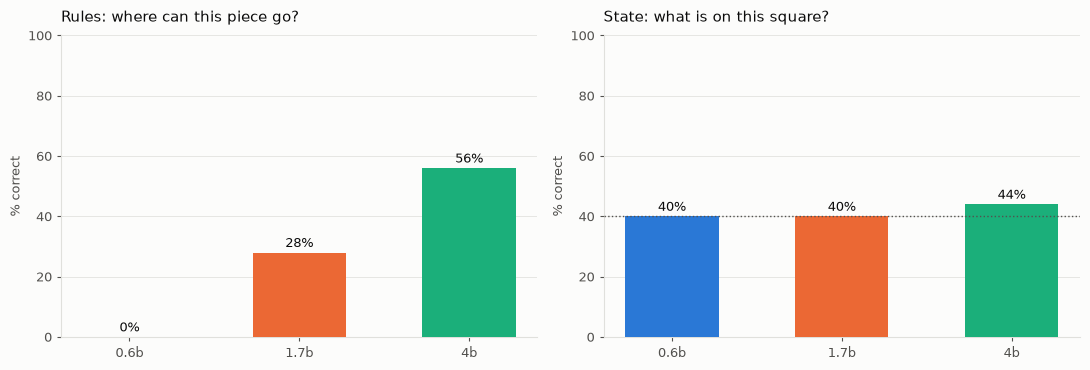

In [3]:
def always_empty_baseline(items):
    """Score of answering "empty" to everything.

    Computed, not assumed: the probe picks occupied-vs-empty per item, so with
    n=25 the split lands wherever it lands. It came out 10/15 here, making the
    trivial baseline 40% rather than the 50% the design intended.
    """
    board = [i for i in items if i["kind"] == "board"]
    return 100 * sum(i["answer"] == "empty" for i in board) / len(board)


BASELINE = always_empty_baseline(probes[order[0]])
print(f'always answering "empty" scores {BASELINE:.0f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), facecolor=SURFACE)

for ax, kind, title in zip(
    axes, ("moves", "board"),
    ("Rules: where can this piece go?", "State: what is on this square?"),
):
    pct = [summary(probes[m], kind)["pct"] for m in order]
    bars = ax.bar(order, pct, width=0.55, color=PALETTE[: len(order)], zorder=3)
    for bar, value in zip(bars, pct):
        ax.annotate(f"{value:.0f}%",
                    xy=(bar.get_x() + bar.get_width() / 2, value),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", color=INK, fontsize=9)

    if kind == "board":
        ax.axhline(BASELINE, color=INK_SOFT, linestyle=":", linewidth=1, zorder=4)
        ax.annotate(f'always say "empty" ({BASELINE:.0f}%)',
                    xy=(len(order) - 0.5, BASELINE), xytext=(0, 5),
                    textcoords="offset points", ha="right",
                    color=INK_SOFT, fontsize=8)

    ax.set_ylim(0, 100)
    ax.set_ylabel("% correct", color=INK_SOFT, fontsize=9)
    ax.set_title(title, color=INK, fontsize=11, loc="left", pad=10)
    style(ax)
    ax.grid(axis="x", visible=False)

fig.tight_layout()

### Squares that don't exist

A chessboard is a1 to h8. Counting answers outside it separates "knows the
movement offsets" from "knows the board has edges".

In [4]:
SQUARE_ANY = re.compile(r"\b[a-h](\d+)\b")

for label in order:
    moves = [i for i in probes[label] if i["kind"] == "moves"]
    bad = [
        f"{m.group(0)}" for i in moves
        for m in SQUARE_ANY.finditer(i["said"].lower())
        if not 1 <= int(m.group(1)) <= 8
    ]
    print(f"{label:6s} off-board squares named: {len(bad):3d}  {sorted(set(bad))[:10]}")

0.6b   off-board squares named:   8  ['b9', 'c9', 'e9', 'f9', 'g9', 'h9']
1.7b   off-board squares named: 157  ['a9', 'b9', 'c9', 'e10', 'e100', 'e101', 'e102', 'e103', 'e104', 'e105']
4b     off-board squares named:   7  ['b9', 'e9', 'f9', 'g9', 'h9']


In [5]:
# Side by side on the same questions.
for idx in range(4):
    item = [i for i in probes[order[0]] if i["kind"] == "moves"][idx]
    piece = item["prompt"].split("white ")[1].split(" on")[0]
    square = item["prompt"].split(" on ")[1].split(".")[0]
    print(f"{piece} on {square}")
    print(f"   want   {' '.join(item['answer'])}")
    for label in order:
        said = [i for i in probes[label] if i["kind"] == "moves"][idx]["said"]
        print(f"   {label:6s} {said[:66]}")
    print()

queen on f7
   want   a2 a7 b3 b7 c4 c7 d5 d7 e6 e7 e8 f1 f2 f3 f4 f5 f6 f8 g6 g7 g8 h5 h7
   0.6b   f6, f8, e6, e8, d6, d8, e7, f7
   1.7b   a2\ b3\ c4\ d5\ e6\ f1\ f2\ f3\ f4\ f5\ f6\ a7\ b7\ c7\ d7\ e7\ g6
   4b     a1 a7 a8 b2 b7 c3 c6 d4 d5 e5 e7 f3 f6 f7 g2 g7 h1 h7 h8

knight on b5
   want   a3 a7 c3 c7 d4 d6
   0.6b   b6\ a4\ b3\ c4
   1.7b   a3\ a7\ c3\ c7\ d4\ d6\ e3\ e6
   4b     d6 d4 c7 c3 a7 a3

king on g8
   want   f7 f8 g7 h7 h8
   0.6b   g7, g9, f7, f9, h7, h9, g6, g7
   1.7b   f7\ f8\ g7\ g9\ h7\ h8
   4b     f7 f8 f9 g7 g9 h7 h8 h9

queen on g5
   want   a5 b5 c1 c5 d2 d5 d8 e3 e5 e7 f4 f5 f6 g1 g2 g3 g4 g6 g7 g8 h4 h5 h6
   0.6b   g1, g2, g3, g4, g6, g7, f5, f6, f7, e5, e6, e7, d5, d6, d7, c5, c6
   1.7b   a5\ b5\ c5\ d5\ e5\ f5\ f4\ f6\ g4\ g6
   4b     a5 b5 c5 d5 e5 f5 h5 g1 g2 g3 g4 g6 g7 g8 f6 e7 d8 h6 f4 e3 d2 c1 



### Same board questions, every model

`want` is ground truth. Watch whether the model names a piece at all, and how
much it wrote to get there.

In [6]:
for idx in range(5):
    ref = [i for i in probes[order[0]] if i["kind"] == "board"][idx]
    square = ref["prompt"].split("What is on square ")[1].split("?")[0]
    plies = ref["prompt"].count(".") - 1
    print(f"square {square}  (after ~{plies} moves)")
    print(f"   want   {ref['answer']}")
    for label in order:
        item = [i for i in probes[label] if i["kind"] == "board"][idx]
        mark = "ok " if item["score"] else "   "
        cut = " [cut off]" if item.get("truncated") else ""
        print(f"   {mark}{label:6s} {item['said'][:52]!r:56s} "
              f"{item.get('tokens', 0):4d} tok{cut}")
    print()

square h4  (after ~21 moves)
   want   black pawn
      0.6b   'empty'                                                     6 tok
      1.7b   '\\text{empty'                                            262 tok
      4b     '\\text{white pawn'                                       277 tok

square f3  (after ~52 moves)
   want   white pawn
      0.6b   'empty'                                                     6 tok
      1.7b   'empty'                                                     6 tok
      4b     'So, the **f3** square is still unchanged from'          1024 tok [cut off]

square g2  (after ~26 moves)
   want   white pawn
      0.6b   'empty'                                                     6 tok
      1.7b   '\\text{empty'                                            764 tok
      4b     'empty'                                                   442 tok

square h1  (after ~12 moves)
   want   empty
   ok 0.6b   'empty'                                                     6 tok
  

### Full reasoning, side by side

The score says what happened. Only the text says why. Change `KIND` and
`INDEX` to walk through the probes.

## Examples: the exact prompt, and what each model replied

One question of each kind, verbatim, with every model's full answer. This is
the ground truth for everything above.

In [ ]:
def show_example(kind, index=0, chars=700):
    ref = [i for i in probes[order[0]] if i["kind"] == kind][index]

    print("=" * 74)
    print(f"PROMPT  ({kind})")
    print("=" * 74)
    print(ref["prompt"])
    print(f"\nCORRECT ANSWER: {ref['answer']}\n")

    for label in order:
        item = [i for i in probes[label] if i["kind"] == kind][index]
        verdict = "CORRECT" if item["score"] else "wrong"
        print("-" * 74)
        print(f"{label}  ->  {verdict}   "
              f"({item.get('tokens', 0)} tokens"
              f"{', truncated' if item.get('truncated') else ''})")
        print(f"extracted: {item['said']!r}")
        print()
        print(item.get("completion", "(no completion saved)")[:chars])
        print()


show_example("moves", index=0)

In [ ]:
show_example("board", index=0, chars=500)

In [7]:
KIND = "moves"   # "moves" or "board"
INDEX = 1
CHARS = 900

ref = [i for i in probes[order[0]] if i["kind"] == KIND][INDEX]
print("PROMPT")
print(ref["prompt"][:400])
print(f"\nWANT: {ref['answer']}")

for label in order:
    item = [i for i in probes[label] if i["kind"] == KIND][INDEX]
    print("\n" + "=" * 72)
    print(f"{label}   score={item['score']:.0f}   "
          f"tokens={item.get('tokens', 0)}   "
          f"truncated={item.get('truncated', False)}")
    print(f"boxed: {item['said']!r}")
    print("-" * 72)
    print(item.get("completion", "(no completion saved)")[:CHARS])

PROMPT
An otherwise empty chess board has a single white knight on b5.
List every square that knight can move to.
Put the squares, separated by spaces, inside \boxed{...}

WANT: ['a3', 'a7', 'c3', 'c7', 'd4', 'd6']

0.6b   score=0   tokens=230   truncated=False
boxed: 'b6\\ a4\\ b3\\ c4'
------------------------------------------------------------------------
We are given a chessboard with a single white knight on square **b5**. We are to list all squares that the knight can move to, and then put them in a box.

### Step-by-step:

- The knight moves in an L-shape: 2 squares in one direction and 1 square in the perpendicular direction.
- The knight starts at **b5**.
- Let's find all possible moves from **b5**.

#### Possible moves from **b5**:
- Move 2 squares to the right (b6), 1 square up (a4)
- Move 2 squares to the left (b3), 1 square up (a4)
- Move 2 squares to the right (b6), 1 square down (c4)
- Move 2 squares to the left (b3), 1 square down (c4)

So the possible squares are:

- 

### Is it even attempting?

A score at the baseline can mean two different things, and the score alone
cannot tell them apart. Counting how often each model actually names a piece
rather than saying "empty" does.

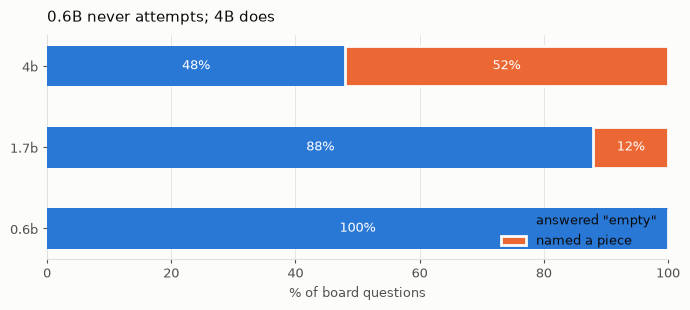

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2), facecolor=SURFACE)

said_empty, attempted = [], []
for label in order:
    board = [i for i in probes[label] if i["kind"] == "board"]
    n_empty = sum("empty" in i["said"].lower() for i in board)
    said_empty.append(100 * n_empty / len(board))
    attempted.append(100 * (len(board) - n_empty) / len(board))

y = range(len(order))
ax.barh(y, said_empty, height=0.5, color=PALETTE[0], zorder=3,
        label='answered "empty"')
ax.barh(y, attempted, height=0.5, left=said_empty, color=PALETTE[1], zorder=3,
        label="named a piece", edgecolor=SURFACE, linewidth=2)

for i, (a, b) in enumerate(zip(said_empty, attempted)):
    if a > 8:
        ax.annotate(f"{a:.0f}%", xy=(a / 2, i), ha="center", va="center",
                    color="white", fontsize=9)
    if b > 8:
        ax.annotate(f"{b:.0f}%", xy=(a + b / 2, i), ha="center", va="center",
                    color="white", fontsize=9)

ax.set_yticks(list(y), order)
ax.set_xlim(0, 100)
ax.set_xlabel("% of board questions", color=INK_SOFT, fontsize=9)
ax.set_title("0.6B never attempts; 4B does", color=INK, fontsize=11,
             loc="left", pad=10)
ax.legend(loc="lower right", frameon=False, fontsize=9, labelcolor=INK)
style(ax)
ax.grid(axis="y", visible=False)
fig.tight_layout()

## 2. Baseline runs: what actually came back

`answered` counts a `\boxed{...}` of any kind, which is too generous. A boxed
value that is not move-shaped is not an attempt. The model echoing the prompt's
own placeholder inflated this badly in the first no-think run.

In [9]:
SAN = re.compile(r"^(O-O-O|O-O|[KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](=[QRBN])?[+#]?)$")


def model_arm(results):
    return next(a for a in results
                if not a["name"].startswith(("random", "stockfish")))


baselines = {
    p.stem: json.load(open(p)) for p in sorted(RUNS.glob("*.json"))
    if not p.stem.startswith(("probe", "p1024"))
}

for name, results in baselines.items():
    rows = model_arm(results)["rows"]
    legal = [r for r in rows if r["legal"]]
    junk = [r for r in rows if r["answered"] and not r["legal"]
            and not SAN.match((r["raw"] or "").strip())]
    illegal = [r for r in rows if r["answered"] and not r["legal"]
               and SAN.match((r["raw"] or "").strip())]
    silent = [r for r in rows if not r["answered"]]
    attempts = len(legal) + len(illegal)

    print(f"{name}  (n={len(rows)})")
    print(f"  legal move         {len(legal):4d}")
    print(f"  illegal move       {len(illegal):4d}")
    print(f"  boxed non-move     {len(junk):4d}  "
          f"{Counter((r['raw'] or '') for r in junk).most_common(2)}")
    print(f"  no answer          {len(silent):4d}")
    if attempts:
        print(f"  -> {len(legal)}/{attempts} real attempts were legal "
              f"({len(legal) / attempts:.0%})")
    print()

movetext-nothink  (n=100)
  legal move           31
  illegal move          3
  boxed non-move       61  [('MOVE', 61)]
  no answer             5
  -> 31/34 real attempts were legal (91%)

movetext-think  (n=100)
  legal move            0
  illegal move          0
  boxed non-move        2  [('MOVE', 2)]
  no answer            98



### What came back, as a picture

Four outcomes, and the summary line collapsed them into one misleading
number. "answered 95%" was mostly the model echoing the prompt's placeholder.

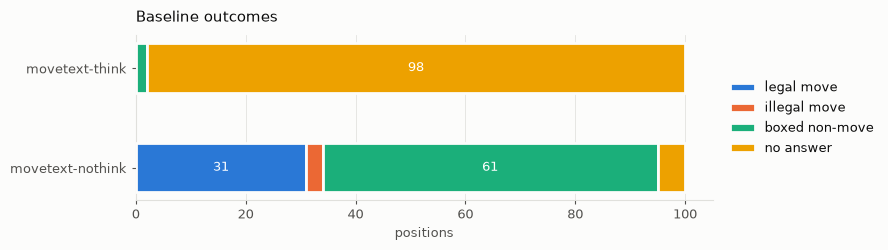

In [10]:
OUTCOMES = ["legal move", "illegal move", "boxed non-move", "no answer"]
OUTCOME_COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

names = list(baselines)
counts = []
for name in names:
    rows = model_arm(baselines[name])["rows"]
    legal = sum(r["legal"] for r in rows)
    illegal = sum(1 for r in rows if r["answered"] and not r["legal"]
                  and SAN.match((r["raw"] or "").strip()))
    junk = sum(1 for r in rows if r["answered"] and not r["legal"]
               and not SAN.match((r["raw"] or "").strip()))
    silent = sum(1 for r in rows if not r["answered"])
    counts.append([legal, illegal, junk, silent])

fig, ax = plt.subplots(figsize=(9, 2.6), facecolor=SURFACE)
left = [0] * len(names)
for i, (outcome, colour) in enumerate(zip(OUTCOMES, OUTCOME_COLOURS)):
    values = [c[i] for c in counts]
    ax.barh(names, values, height=0.5, left=left, color=colour, zorder=3,
            label=outcome, edgecolor=SURFACE, linewidth=2)
    for j, value in enumerate(values):
        if value >= 8:
            ax.annotate(str(value), xy=(left[j] + value / 2, j),
                        ha="center", va="center", color="white", fontsize=9)
    left = [l + v for l, v in zip(left, values)]

ax.set_xlabel("positions", color=INK_SOFT, fontsize=9)
ax.set_title("Baseline outcomes", color=INK, fontsize=11, loc="left", pad=10)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False,
          fontsize=9, labelcolor=INK)
style(ax)
ax.grid(axis="y", visible=False)
fig.tight_layout()

## 3. Move quality against the references

Only over moves that were legal. Below the random line means the model's
*choices* are worse than chance: plausible-looking moves picked without
reference to the position.

In [11]:
for name, results in baselines.items():
    print(name)
    for arm in results:
        losses = [r["cp_loss"] for r in arm["rows"] if r["cp_loss"] is not None]
        if losses:
            good = sum(x <= 50 for x in losses) / len(losses)
            print(f"   {arm['name'][:34]:36s} n={len(losses):3d}  "
                  f"mean {st.mean(losses):5.0f}  median {st.median(losses):5.0f}  "
                  f"good {good:5.1%}")
        else:
            print(f"   {arm['name'][:34]:36s} no legal moves")
    print()

movetext-nothink
   random legal move                    n=100  mean   416  median   438  good  7.0%
   stockfish best                       n=100  mean    11  median     0  good 98.0%
   qwen3-0.6B legal=True think=False    n= 31  mean   535  median   517  good  3.2%

movetext-think
   random legal move                    n=100  mean   416  median   438  good  7.0%
   stockfish best                       n=100  mean    11  median     0  good 98.0%
   qwen3-0.6B legal=True think=True     no legal moves



### Move quality

Cumulative, so you read medians straight off 0.5. Left and up is better. The
model curve sitting right of random means its choices are worse than chance.

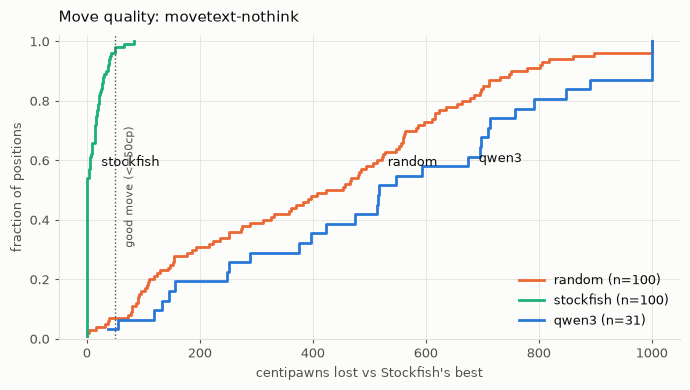

In [12]:
fig, ax = plt.subplots(figsize=(7, 4), facecolor=SURFACE)

RUN_FOR_ECDF = "movetext-nothink"
colours = {"random": "#eb6834", "stockfish": "#1baf7a", "qwen3": "#2a78d6"}

for arm in baselines[RUN_FOR_ECDF]:
    losses = sorted(r["cp_loss"] for r in arm["rows"] if r["cp_loss"] is not None)
    if not losses:
        continue
    key = ("random" if arm["name"].startswith("random")
           else "stockfish" if arm["name"].startswith("stockfish") else "qwen3")
    fraction = [(i + 1) / len(losses) for i in range(len(losses))]
    ax.step(losses, fraction, where="post", color=colours[key], linewidth=2,
            label=f"{key} (n={len(losses)})")

    at = next((i for i, f in enumerate(fraction) if f >= 0.6), len(losses) - 1)
    ax.annotate(key, xy=(losses[at], fraction[at]), xytext=(8, -4),
                textcoords="offset points", color=INK, fontsize=9)

ax.axvline(50, color=INK_SOFT, linestyle=":", linewidth=1)
ax.annotate("good move (<=50cp)", xy=(50, 0.5),
            xycoords=ax.get_xaxis_transform(), xytext=(6, 0),
            textcoords="offset points", color=INK_SOFT, fontsize=8,
            rotation=90, va="center")

ax.set_xlabel("centipawns lost vs Stockfish's best", color=INK_SOFT, fontsize=9)
ax.set_ylabel("fraction of positions", color=INK_SOFT, fontsize=9)
ax.set_title(f"Move quality: {RUN_FOR_ECDF}", color=INK, fontsize=11,
             loc="left", pad=10)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right", frameon=False, fontsize=9, labelcolor=INK)
style(ax)
fig.tight_layout()

## 4. Degenerate-policy check

A published GRPO run on 8B models converged on pushing the a-pawn over 80% of
the time. Nearly always legal, rarely catastrophic, and the best constant answer
when you can't read a board. Mean cp_loss improves the whole way. **This is what
separates learning from collapse.**

In [13]:
for name, results in baselines.items():
    played = [r["move"] for r in model_arm(results)["rows"] if r.get("move")]
    if not played:
        print(f"{name}: no legal moves\n")
        continue
    counts = Counter(played).most_common(8)
    top, n_top = counts[0]
    share = n_top / len(played)
    flag = "   <- DEGENERATE" if share >= 0.20 else ""
    print(f"{name}: {len(played)} legal, top '{top}' at {share:.0%}{flag}")
    print(f"   {counts}\n")

movetext-nothink: 31 legal, top 'Bb5' at 10%
   [('Bb5', 3), ('Nc3', 2), ('Bf5', 2), ('Kc5', 2), ('Qd5', 1), ('Qh5', 1), ('Bb4', 1), ('Qe2', 1)]

movetext-think: no legal moves



### Which moves it plays

The degenerate-policy detector. A tall first bar means a constant answer, not
chess. The dashed line is what a uniform pick over the legal moves would give.

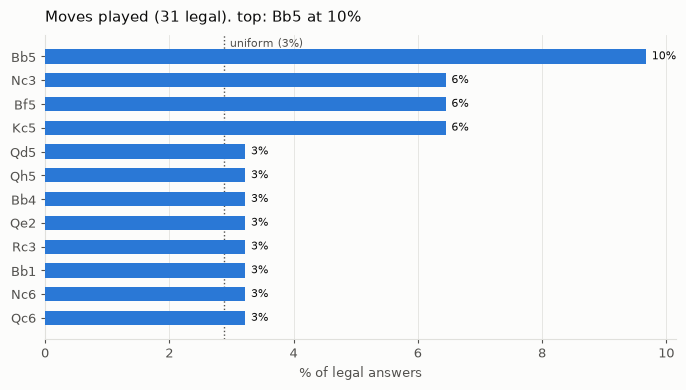

In [14]:
RUN_FOR_MOVES = "movetext-nothink"
played = [r["move"] for r in model_arm(baselines[RUN_FOR_MOVES])["rows"]
          if r.get("move")]

if played:
    counts = Counter(played).most_common(12)
    labels = [m for m, _ in counts][::-1]
    shares = [100 * n / len(played) for _, n in counts][::-1]

    fig, ax = plt.subplots(figsize=(7, 4), facecolor=SURFACE)
    ax.barh(labels, shares, height=0.6, color=PALETTE[0], zorder=3)
    for y, share in enumerate(shares):
        ax.annotate(f"{share:.0f}%", xy=(share, y), xytext=(4, 0),
                    textcoords="offset points", va="center",
                    color=INK, fontsize=8)

    uniform = 100 / st.mean(
        len(list(__import__("chess").Board(r["fen"]).legal_moves))
        for r in model_arm(baselines[RUN_FOR_MOVES])["rows"] if r.get("fen")
    )
    ax.axvline(uniform, color=INK_SOFT, linestyle=":", linewidth=1)
    ax.annotate(f"uniform ({uniform:.0f}%)", xy=(uniform, len(labels) - 0.6),
                xytext=(4, 0), textcoords="offset points",
                color=INK_SOFT, fontsize=8)

    top, n_top = counts[0]
    share = 100 * n_top / len(played)
    flag = "  <- degenerate" if share >= 20 else ""
    ax.set_title(f"Moves played ({len(played)} legal). top: {top} at "
                 f"{share:.0f}%{flag}", color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("% of legal answers", color=INK_SOFT, fontsize=9)
    style(ax)
    ax.grid(axis="y", visible=False)
    fig.tight_layout()
else:
    print(f"{RUN_FOR_MOVES}: no legal moves to plot")

## 5. Read a completion

Numbers say a run failed. Only the text says why.

In [15]:
RUN = "movetext-nothink"  # change to inspect another run
INDEX = 0

row = model_arm(baselines[RUN])["rows"][INDEX]
print(f"raw    {row['raw']!r}")
print(f"move   {row['move']}   legal={row['legal']}  cp_loss={row['cp_loss']}")
print(f"tokens {row['tokens']}  truncated={row['truncated']}")
print("\n--- completion ---")
print(row["completion"][:1200])

raw    'MOVE'
move   None   legal=False  cp_loss=None
tokens 6  truncated=False

--- completion ---
\boxed{MOVE}
